### Imports

In [26]:
import pickle
import os
import sys
import torch
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from torch.nn.functional import interpolate

In [27]:
sys.path.append('/home/omer/git/AutoDS3D')

In [28]:
from DS3Dplus.ds3d_utils import ImModel, Volume2XYZ

### Functions

In [29]:
import copy

def _compute_overlay(im, xyzps, param_dict):
    if xyzps is None or im is None:
        print('One of the inputs is empty.')
        return None, None, None, None
    xyz_rec = xyzps[:, :3]
    H, W = im.shape

    # deep copy to avoid mutating the original param_dict
    pd_local = copy.deepcopy(param_dict)
    pd_local['H'], pd_local['W'] = H, W

    if H > pd_local['phase_mask'].shape[0] or W > pd_local['phase_mask'].shape[1]:
        sf = max(H // pd_local['phase_mask'].shape[0] + 1, W // pd_local['phase_mask'].shape[1] + 1)
        pd_local['ps_BFP'] /= sf
        phase_mask = pd_local['phase_mask']
        HW = np.floor(pd_local['f_4f'] * pd_local['lamda'] / (
                pd_local['ps_camera'] * pd_local['ps_BFP']))
        HW = int(HW + 1 - (HW % 2))

        phase_mask = interpolate(torch.tensor(phase_mask).unsqueeze(0).unsqueeze(1), size=(HW, HW))
        pd_local['phase_mask'] = phase_mask[0, 0].numpy()

    model = ImModel(pd_local)

    # nphotons_rec = (pd_local['Nsig_range'][0]+pd_local['Nsig_range'][1])/2 * np.ones(xyz_rec.shape[0])
    # psfs_rec = model.get_psfs(torch.from_numpy(np.c_[xyz_rec, nphotons_rec]).to(device)).cpu().numpy()
    im_norm = (im - im.min()) / (im.max() - im.min())

    ps_xy = pd_local['vs_xy'] * pd_local['us_factor']

    del model
    torch.cuda.empty_cache()

    return im_norm, xyz_rec, ps_xy


def select_strongest_localizations_by_radius(
    localizations,
    radius,
    x_col='x [nm]',
    y_col='y [nm]',
    intensity_col='intensity [au]',
):
    """Group nearby localizations in x/y and keep the strongest one per group."""
    if radius < 0:
        raise ValueError('radius must be non-negative.')

    if isinstance(localizations, pd.DataFrame):
        df = localizations.copy()
    else:
        df = pd.DataFrame(localizations)

    required_columns = [x_col, y_col, intensity_col]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    if df.empty:
        return df.iloc[0:0].copy()

    from scipy.spatial import cKDTree

    coords = df[[x_col, y_col]].to_numpy(dtype=np.float64)
    tree = cKDTree(coords)
    visited = np.zeros(len(df), dtype=bool)
    selected_indices = []

    for start_idx in range(len(df)):
        if visited[start_idx]:
            continue

        component = []
        stack = [start_idx]
        visited[start_idx] = True

        while stack:
            current_idx = stack.pop()
            component.append(current_idx)
            neighbor_indices = tree.query_ball_point(coords[current_idx], radius)

            for neighbor_idx in neighbor_indices:
                if not visited[neighbor_idx]:
                    visited[neighbor_idx] = True
                    stack.append(neighbor_idx)

        component_df = df.iloc[component]
        strongest_index = component_df[intensity_col].astype(float).idxmax()
        selected_indices.append(strongest_index)

    return df.loc[selected_indices].sort_index().reset_index(drop=True)


def bias_comparison(param_dict, xyzps_baseline, im_baseline, xyzps_corrected, im_corrected, device):
    im_b, xyz_b, ps_xy = _compute_overlay(im_baseline, xyzps_baseline, param_dict)
    im_c, xyz_c, ps_xy = _compute_overlay(im_corrected, xyzps_corrected, param_dict)

    fig, axes = plt.subplots(1, 2, figsize=(10, 10))

    axes[0].imshow(im_b, cmap='gray')
    axes[0].plot(xyz_b[:, 0] / (ps_xy*1000), xyz_b[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[0].set_title('Baseline')
    axes[0].axis('off')

    axes[1].imshow(im_c, cmap='gray')
    axes[1].plot(xyz_c[:, 0] / (ps_xy*1000), xyz_c[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[1].set_title('Corrected')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [30]:
def overlay_images_rg(im1: np.ndarray, im2: np.ndarray,
                      title: str = "",
                      figsize: tuple = (8, 8),
                      show: bool = True) -> np.ndarray:
    """Overlay two single-channel images with im1 in red and im2 in green.

    Each image is normalized independently to [0, 1] before compositing, so
    the dynamic range mismatch between channels does not hide structure.
    Pixels present in both images appear yellow; pixels unique to im1 appear
    red and pixels unique to im2 appear green.

    Args:
        im1: 2D array (H, W), shown as the red channel.
        im2: 2D array (H, W), shown as the green channel.
        title: Optional figure title.
        figsize: Matplotlib figure size in inches.
        show: If True, display the figure immediately.

    Returns:
        RGB overlay array of shape (H, W, 3), dtype float32, values in [0, 1].
    """
    def _norm(im):
        im = np.asarray(im, dtype=np.float32)
        lo, hi = im.min(), im.max()
        if hi > lo:
            return (im - lo) / (hi - lo)
        return np.zeros_like(im)

    r = _norm(im1)
    g = _norm(im2)
    rgb = np.stack([r, g, np.zeros_like(r)], axis=-1)

    if show:
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(rgb)
        if title:
            ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    return rgb

In [31]:
from scipy.optimize import linear_sum_assignment


def match_localizations_hungarian(
    locs_a: np.ndarray,
    locs_b: np.ndarray,
    label_a: str = "Set A",
    label_b: str = "Set B",
    max_distance: float = np.inf,
    pixel_size_nm: float = None,
    figsize: tuple = (14, 10),
    xy_max: float = 1200
) -> dict:
    """Match two sets of 3D localizations with the Hungarian algorithm.

    Args:
        locs_a: Array (N, 3+), columns [x, y, z, ...] in nm.
        locs_b: Array (M, 3+), columns [x, y, z, ...] in nm.
        label_a: Legend label for the first set.
        label_b: Legend label for the second set.
        max_distance: Reject matched pairs with 3D distance above this (nm).
        pixel_size_nm: If provided, XY scatter is shown in pixels (divide nm
            coords by this value). Pass ps_xy * 1000 to match bias_comparison.
        figsize: Matplotlib figure size in inches.
    """
    a = np.asarray(locs_a, dtype=np.float64)[:, :3]
    b = np.asarray(locs_b, dtype=np.float64)[:, :3]

    diff = a[:, np.newaxis, :] - b[np.newaxis, :, :]
    cost = np.sqrt((diff ** 2).sum(axis=-1))

    row_idx, col_idx = linear_sum_assignment(cost)
    matched_3d = cost[row_idx, col_idx]

    keep = matched_3d <= max_distance
    row_idx, col_idx = row_idx[keep], col_idx[keep]

    d = a[row_idx] - b[col_idx]
    lateral_errors = np.sqrt(d[:, 0] ** 2 + d[:, 1] ** 2)
    depth_errors   = np.abs(d[:, 2])

    mean_lateral = float(lateral_errors.mean()) if len(lateral_errors) else np.nan
    mean_depth   = float(depth_errors.mean())   if len(depth_errors)   else np.nan

    print(f"Matched pairs : {len(row_idx)}")
    print(f"Mean lateral  : {mean_lateral:.2f} nm")
    print(f"Mean depth    : {mean_depth:.2f} nm")

    # convert to pixels for XY plot if pixel_size_nm is given
    scale = pixel_size_nm if pixel_size_nm is not None else 1.0
    xy_unit = 'pixels' if pixel_size_nm is not None else 'nm'
    ax_x = a[:, 0] / scale
    ax_y = a[:, 1] / scale
    bx_x = b[:, 0] / scale
    bx_y = b[:, 1] / scale

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

    ax_xy = fig.add_subplot(gs[0, :])
    ax_xy.scatter(ax_x, ax_y, s=12, c='tab:red',  alpha=0.7, label=label_a, zorder=3)
    ax_xy.scatter(bx_x, bx_y, s=12, c='tab:blue', alpha=0.7, label=label_b, zorder=3)
    # for r, c in zip(row_idx, col_idx):
    #     ax_xy.plot([ax_x[r], bx_x[c]], [ax_y[r], bx_y[c]],
    #                color='gray', lw=0.6, alpha=0.5)
    ax_xy.set_xlim(0, xy_max)
    ax_xy.set_ylim(0, xy_max)
    ax_xy.invert_yaxis()
    ax_xy.set_aspect('equal')
    ax_xy.set_xlabel(f'X ({xy_unit})')
    ax_xy.set_ylabel(f'Y ({xy_unit})')
    ax_xy.set_title('XY view — matched pairs')
    ax_xy.legend()

    ax_lat = fig.add_subplot(gs[1, 0])
    ax_lat.hist(lateral_errors, bins=30, color='tab:orange', edgecolor='k', linewidth=0.4)
    ax_lat.axvline(mean_lateral, color='k', linestyle='--', label=f'mean={mean_lateral:.1f} nm')
    ax_lat.set_xlabel('Lateral distance (nm)')
    ax_lat.set_ylabel('Count')
    ax_lat.set_title('Lateral error distribution')
    ax_lat.legend()

    ax_dep = fig.add_subplot(gs[1, 1])
    ax_dep.hist(depth_errors, bins=30, color='tab:purple', edgecolor='k', linewidth=0.4)
    ax_dep.axvline(mean_depth, color='k', linestyle='--', label=f'mean={mean_depth:.1f} nm')
    ax_dep.set_xlabel('Depth |ΔZ| (nm)')
    ax_dep.set_ylabel('Count')
    ax_dep.set_title('Depth error distribution')
    ax_dep.legend()

    plt.suptitle(
        f'{label_a} vs {label_b}  |  n={len(row_idx)}  |  '
        f'lateral={mean_lateral:.1f} nm  depth={mean_depth:.1f} nm',
        fontsize=11,
    )
    plt.show()

    return {
        'mean_lateral_nm': mean_lateral,
        'mean_depth_nm':   mean_depth,
        'n_matched':       len(row_idx),
        'lateral_errors':  lateral_errors,
        'depth_errors':    depth_errors,
        'row_idx':         row_idx,
        'col_idx':         col_idx,
    }


In [32]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def match_localizations_hungarian(locs_a, locs_b, max_distance=None):
    """Match two sets of localizations with the Hungarian algorithm and return mean distance.

    Args:
        locs_a: (N, D) array of localizations in nm.
        locs_b: (M, D) array of localizations in nm.
        max_distance: optional distance cutoff (nm); matched pairs beyond this are excluded.

    Returns:
        mean_dist: mean Euclidean distance of matched pairs in nm.
        dists: (K,) array of individual matched distances after filtering.
        row_ind: (K,) indices into locs_a for each matched pair.
        col_ind: (K,) indices into locs_b for each matched pair.
    """
    C = cdist(locs_a, locs_b, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(C)
    dists = C[row_ind, col_ind]
    if max_distance is not None:
        keep = dists <= max_distance
        row_ind, col_ind, dists = row_ind[keep], col_ind[keep], dists[keep]
    return float(np.mean(dists)), dists, row_ind, col_ind


In [33]:
def plot_lateral_error_vs_optical_distance(
    locs_eval: np.ndarray,
    lateral_errors: np.ndarray,
    col_idx: np.ndarray,
    optical_center: tuple = (647, 561),
    n_bins: int = 8,
    label: str = "",
    pixel_size_nm: float = None,
    figsize: tuple = (8, 6),
) -> None:
    """Plot lateral localization error and detection count vs distance from the optical axis.

    A single axes shows:
      - Bottom x-axis (blue): mean ± std lateral error per distance bin.
      - Top x-axis (orange): detection count per bin as horizontal bars (same y-axis).

    Parameters
    ----------
    locs_eval : (M, 2+) array
        Evaluated localizations in pixel coordinates [x, y, ...].
    lateral_errors : (K,) array
        Per-pair lateral errors from Hungarian matching (same units as locs_eval).
    col_idx : (K,) int array
        Indices into locs_eval for each matched pair.
    optical_center : (cx, cy)
        Optical axis center in pixel coordinates. Default (647, 561).
    n_bins : int
        Number of distance bins.
    label : str
        Optional figure title.
    pixel_size_nm : float, optional
        Pixel size in nm. If provided, axes are shown in nm instead of pixels.
    figsize : tuple
        Figure size in inches.
    """
    cx, cy = optical_center
    matched_locs = np.asarray(locs_eval)[col_idx]

    dists_to_center = np.sqrt(
        (matched_locs[:, 0] - cx) ** 2 + (matched_locs[:, 1] - cy) ** 2
    )

    bin_edges = np.linspace(0, dists_to_center.max() * 1.001, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    bin_indices = np.clip(np.digitize(dists_to_center, bin_edges) - 1, 0, n_bins - 1)

    mean_errors = np.full(n_bins, np.nan)
    std_errors = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        mask = bin_indices == b
        if mask.sum() > 0:
            mean_errors[b] = lateral_errors[mask].mean()
            std_errors[b] = lateral_errors[mask].std()
            counts[b] = mask.sum()

    scale = pixel_size_nm if pixel_size_nm is not None else 1.0
    unit = 'nm' if pixel_size_nm is not None else 'pixels'
    valid = ~np.isnan(mean_errors)

    fig, ax1 = plt.subplots(figsize=figsize)

    # Top x-axis: detection count bars (drawn first so they sit behind the error line)
    ax2 = ax1.twiny()
    ax2.barh(
        bin_centers[valid] * scale,
        counts[valid],
        height=bin_width * scale * 0.7,
        color='tab:orange', alpha=0.35, edgecolor='tab:orange', linewidth=0.5,
        label='detection count',
    )
    ax2.set_xlabel('Detection count', color='tab:orange')
    ax2.tick_params(axis='x', labelcolor='tab:orange')
    ax2.spines['top'].set_color('tab:orange')

    # Bottom x-axis: lateral error line + errorbars
    ax1.errorbar(
        mean_errors[valid] * scale,
        bin_centers[valid] * scale,
        xerr=std_errors[valid] * scale,
        fmt='o-', color='tab:blue', capsize=4, linewidth=1.5, markersize=5,
        label='mean ± std lateral error', zorder=3,
    )
    ax1.set_xlabel(f'Lateral error ({unit})', color='tab:blue')
    ax1.set_ylabel(f'Distance from optical axis ({unit})')
    ax1.tick_params(axis='x', labelcolor='tab:blue')
    ax1.spines['bottom'].set_color('tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Combined legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc='lower right')

    if label:
        fig.suptitle(label, fontsize=11, y=1.02)

    plt.tight_layout()
    plt.show()


### Inputs

In [34]:
param_dict_path = '/home/omer/data/mse3/test_of_axis/nfp_minus3p5_z_0_to_3p2/train_data_120x120/param.pickle'

In [35]:
with open(param_dict_path, 'rb') as handle:
    param_dict = pickle.load(handle)

In [36]:
device = 'cuda:2'
param_dict['device'] = device
localization_th = 40 # nm
param_dict['threshold'] = 10
ps_xy = param_dict['vs_xy'] * param_dict['us_factor']

In [37]:
ps_xy

0.11

In [38]:
model = ImModel(param_dict)
volume2xyz = Volume2XYZ(param_dict)

In [39]:
baseline_dir = '/home/omer/data/mse3/train_data/baseline'
corrected_dir = '/home/omer/data/mse3/train_data/corrected'

In [40]:
import matplotlib.cm as cm
from scipy.optimize import linear_sum_assignment

In [41]:
def compute_jaccard_per_bin(xyz_ref, xyz_det, optical_center, radius_bins, thresholds):
    """Compute Jaccard index per cumulative radial zone as a function of matching threshold.

    Each zone is [0, r_hi) — all points within that radius from the optical center.
    Hungarian matching is performed locally within each cumulative zone.

    Args:
        xyz_ref: (N, 2) reference coordinates.
        xyz_det: (M, 2) detection coordinates.
        optical_center: (cx, cy).
        radius_bins: 1-D array of outer-edge radii, e.g. [150, 300, 450, ...].
            Zone b covers [0, radius_bins[b]).
        thresholds: 1-D array of matching distance thresholds to sweep.

    Returns:
        jaccard_curves: (n_bins, n_thresholds) Jaccard values.
        optimal_thresholds: (n_bins,) minimum threshold that maximises Jaccard per zone.
        bin_radii: (n_bins,) outer-edge radius of each cumulative zone.
    """
    cx, cy = optical_center
    bin_radii = np.asarray(radius_bins)
    n_bins = len(bin_radii)

    r_ref = np.sqrt((xyz_ref[:, 0] - cx)**2 + (xyz_ref[:, 1] - cy)**2)
    r_det = np.sqrt((xyz_det[:, 0] - cx)**2 + (xyz_det[:, 1] - cy)**2)

    jaccard_curves = np.zeros((n_bins, len(thresholds)))

    for b, r_hi in enumerate(bin_radii):
        refs_b = xyz_ref[r_ref < r_hi]
        dets_b = xyz_det[r_det < r_hi]
        n_ref_b, n_det_b = len(refs_b), len(dets_b)

        if n_ref_b == 0 or n_det_b == 0:
            continue

        C = cdist(dets_b, refs_b)           # (n_det_b, n_ref_b)
        row_ind, col_ind = linear_sum_assignment(C)
        match_dists = C[row_ind, col_ind]

        for t_idx, T in enumerate(thresholds):
            tp = int(np.sum(match_dists < T))
            denom = n_det_b + n_ref_b - tp
            jaccard_curves[b, t_idx] = tp / denom if denom > 0 else 0.0

    # argmax returns the FIRST index of the maximum => minimum threshold to reach peak J
    optimal_thresholds = thresholds[np.argmax(jaccard_curves, axis=1)]
    return jaccard_curves, optimal_thresholds, bin_radii

In [ ]:
def evaluate_jaccard_vs_radius(
    xyz_ref,
    xyz_det,
    optical_center,
    radius_bins,
    thresholds=None,
    n_thresholds=100,
    fov_size=None,
    title='',
    ps_xy=110
):
    """Find and plot the threshold maximising Jaccard per cumulative radial zone.

    All spatial inputs (xyz_ref, xyz_det, optical_center, radius_bins, thresholds)
    must be in **pixels** — the same unit used by match_localizations_hungarian.
    Legend labels are converted to μm using ps_xy.

    Args:
        xyz_ref: (N, 2) reference coordinates in pixels.
        xyz_det: (M, 2) detection coordinates in pixels.
        optical_center: (cx, cy) in pixels.
        radius_bins: 1-D array of outer-edge radii in pixels for each cumulative zone.
        thresholds: Thresholds to sweep (pixels). Auto-ranged if None.
        n_thresholds: Steps when auto-ranging.
        fov_size: (W, H) in pixels. Inferred from data if None.
        title: Optional suffix for the figure suptitle.
        ps_xy: Pixel size in nm/px (default 110 nm/px).

    Returns:
        fig: matplotlib Figure.
        optimal_thresholds: (n_bins,) minimum threshold per zone (pixels).
        jaccard_curves: (n_bins, n_thresholds) Jaccard array.
        bin_radii: (n_bins,) outer-edge radii (pixels).
    """
    scale = ps_xy / 1000  # nm/px → μm/px

    if thresholds is None:
        C = cdist(xyz_det, xyz_ref)
        max_useful = np.percentile(C.min(axis=0), 90) * 3
        thresholds = np.linspace(0, max_useful, n_thresholds)

    jaccard_curves, optimal_thresholds, bin_radii = compute_jaccard_per_bin(
        xyz_ref, xyz_det, optical_center, radius_bins, thresholds
    )

    n_bins = len(bin_radii)
    max_jaccards = np.max(jaccard_curves, axis=1)
    norm = plt.Normalize(bin_radii[0], bin_radii[-1])
    colors = cm.viridis(norm(bin_radii))

    cx, cy = optical_center
    if fov_size is None:
        all_pts = np.vstack([xyz_ref, xyz_det])
        fov_size = (int(all_pts[:, 0].max()) + 1, int(all_pts[:, 1].max()) + 1)
    W, H = fov_size

    fig, ax = plt.subplots(1, 1, figsize=(20, 6))
    suptitle = f'Jaccard vs radius—{title}' if title else 'Jaccard vs radius'
    fig.suptitle(suptitle, fontsize=13)

    # ── FOV with concentric circles ───────────────────────────────

    n_show = min(300, len(xyz_ref))
    idx = np.random.default_rng(0).choice(len(xyz_ref), n_show, replace=False)
    ax.scatter(xyz_ref[idx, 0], xyz_ref[idx, 1],
                s=3, c='lightgray', zorder=1)
    ax.scatter(cx, cy, c='red', s=120, marker='+', zorder=6, linewidths=2.5)

    for b in range(n_bins):
        r_hi = bin_radii[b]
        circle = plt.Circle((cx, cy), r_hi, fill=False,
                             color=colors[b], lw=1.8, zorder=4)
        ax.add_patch(circle)
        ax.plot([], [], color=colors[b], lw=2,
                 label=(
                     f'r < {r_hi * scale:.1f} μm  '
                     f'J={max_jaccards[b]:.3f}  '
                     f'T={optimal_thresholds[b] * scale:.2f} μm'
                 ))

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)      # y=0 at top, matching image convention
    ax.set_aspect('equal')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    ax.set_title('Radial zones around optical center')
    ax.legend(fontsize=7, loc='lower right', title='zone   max-J   min-T')
    ax.grid(True, ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig, optimal_thresholds, jaccard_curves, bin_radii


In [ ]:
def evaluate_jaccard_vs_radius2(
    xyz_ref,
    xyz_det,
    optical_center,
    radius_bins,
    thresholds=None,
    n_thresholds=100,
    fov_size=None,
    title='',
    ps_xy=0.11
):
    """Find and plot the threshold maximising Jaccard per cumulative radial zone.

    Plots the FOV with concentric circles centred at the optical center (origin).
    All coordinates and legend values are displayed in μm.

    All spatial inputs (xyz_ref, xyz_det, optical_center, radius_bins, thresholds)
    must be in **pixels** — the same unit used by match_localizations_hungarian.

    Args:
        xyz_ref: (N, 2) reference coordinates in pixels.
        xyz_det: (M, 2) detection coordinates in pixels.
        optical_center: (cx, cy) in pixels.
        radius_bins: 1-D array of outer-edge radii in pixels for each cumulative zone.
        thresholds: Thresholds to sweep (pixels). Auto-ranged if None.
        n_thresholds: Steps when auto-ranging.
        fov_size: (W, H) in pixels. Inferred from data if None.
        title: Optional suffix for the figure suptitle.
        ps_xy: Pixel size in μm/px (default 0.11 μm/px = 110 nm/px).

    Returns:
        fig: matplotlib Figure.
        optimal_thresholds: (n_bins,) minimum threshold per zone (pixels).
        jaccard_curves: (n_bins, n_thresholds) Jaccard array.
        bin_radii: (n_bins,) outer-edge radii (pixels).
    """
    scale = ps_xy  # μm/px

    cx, cy = optical_center
    r_ref = np.sqrt((xyz_ref[:, 0] - cx)**2 + (xyz_ref[:, 1] - cy)**2)
    r_det = np.sqrt((xyz_det[:, 0] - cx)**2 + (xyz_det[:, 1] - cy)**2)

    bin_radii = np.asarray(radius_bins)
    n_bins = len(bin_radii)

    if thresholds is None:
        C = cdist(xyz_det, xyz_ref)
        max_useful = np.percentile(C.min(axis=0), 90) * 3
        thresholds = np.linspace(0, max_useful, n_thresholds)

    # Per-bin Jaccard sweep using match_localizations_hungarian
    jaccard_curves = np.zeros((n_bins, len(thresholds)))

    for b, r_hi in enumerate(bin_radii):
        refs_b = xyz_ref[r_ref < r_hi]
        dets_b = xyz_det[r_det < r_hi]
        n_ref_b, n_det_b = len(refs_b), len(dets_b)

        if n_ref_b == 0 or n_det_b == 0:
            continue

        # match_localizations_hungarian returns distances in the same units as input (pixels)
        _, match_dists, _, _ = match_localizations_hungarian(dets_b, refs_b)

        for t_idx, T in enumerate(thresholds):
            tp = int(np.sum(match_dists < T))
            denom = n_det_b + n_ref_b - tp
            jaccard_curves[b, t_idx] = tp / denom if denom > 0 else 0.0

    # argmax → FIRST index of maximum = minimum threshold to reach peak Jaccard
    optimal_thresholds = thresholds[np.argmax(jaccard_curves, axis=1)]
    max_jaccards = np.max(jaccard_curves, axis=1)

    norm = plt.Normalize(bin_radii[0], bin_radii[-1])
    colors = cm.viridis(norm(bin_radii))

    if fov_size is None:
        all_pts = np.vstack([xyz_ref, xyz_det])
        fov_size = (int(all_pts[:, 0].max()) + 1, int(all_pts[:, 1].max()) + 1)
    W, H = fov_size

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    suptitle = f'Jaccard vs radius—{title}' if title else 'Jaccard vs radius'
    fig.suptitle(suptitle, fontsize=13)

    # Scatter reference points shifted to optical-center origin, in μm
    n_show = min(300, len(xyz_ref))
    idx = np.random.default_rng(0).choice(len(xyz_ref), n_show, replace=False)
    ax.scatter((xyz_ref[idx, 0] - cx) * scale,
               (xyz_ref[idx, 1] - cy) * scale,
               s=3, c='lightgray', zorder=1)

    # Optical center at origin
    ax.scatter(0, 0, c='red', s=120, marker='+', zorder=6, linewidths=2.5)

    # Concentric circles centred at (0, 0), radii in μm
    for b in range(n_bins):
        r_hi = bin_radii[b]
        r_hi_um = r_hi * scale
        circle = plt.Circle((0, 0), r_hi_um, fill=False,
                             color=colors[b], lw=1.8, zorder=4)
        ax.add_patch(circle)
        ax.plot([], [], color=colors[b], lw=2,
                label=(
                    f'r < {r_hi_um:.1f} μm  '
                    f'J={max_jaccards[b]:.3f}  '
                    f'T={optimal_thresholds[b] * scale:.2f} μm'
                ))

    # Grid lines through optical center
    ax.axhline(0, color='k', lw=0.5, zorder=2)
    ax.axvline(0, color='k', lw=0.5, zorder=2)

    # Axis limits in μm, centred at optical center; y inverted to match image convention
    ax.set_xlim(-cx * scale, (W - cx) * scale)
    ax.set_ylim((H - cy) * scale, -cy * scale)
    ax.set_aspect('equal')
    ax.set_xlabel('X (μm)')
    ax.set_ylabel('Y (μm)')
    ax.set_title('Radial zones around optical center')
    ax.legend(fontsize=7, loc='lower right', title='zone   max-J   min-T')
    ax.grid(True, ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig, optimal_thresholds, jaccard_curves, bin_radii


Processing frame frame_0015 at depth 3200 nm...


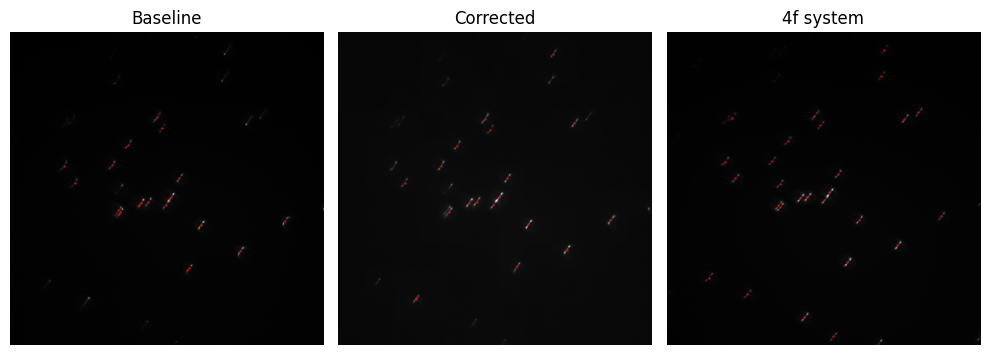

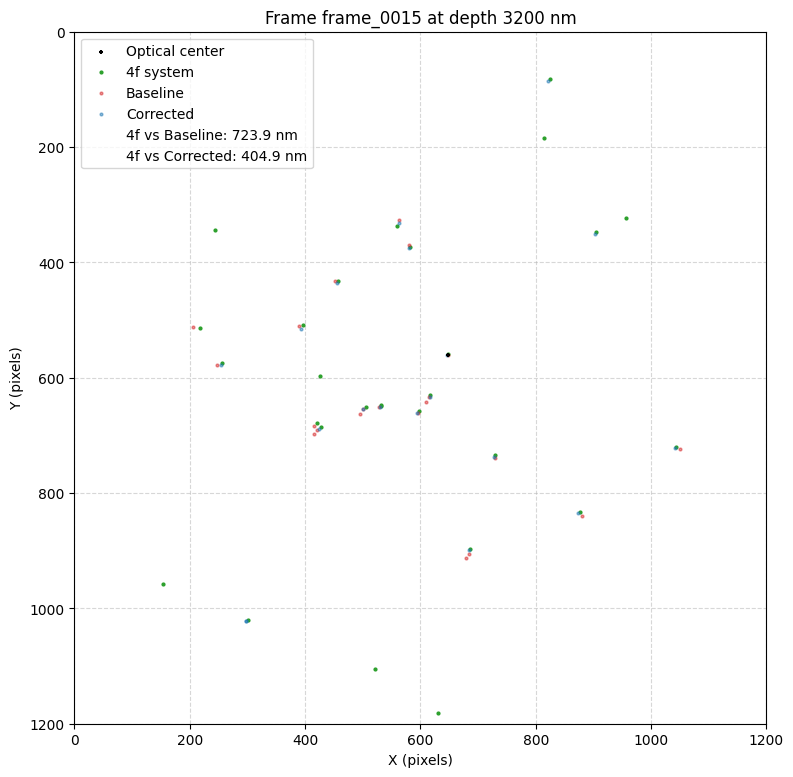

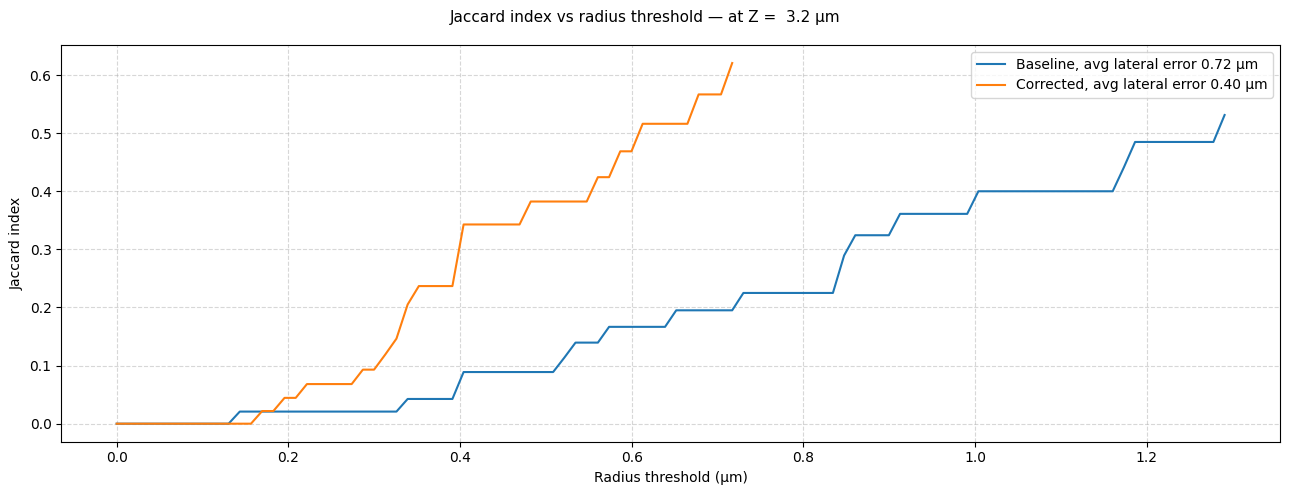

In [ ]:
ji_baseline_all_z_planes = []
ji_corrected_all_z_planes = []

radi_baseline_all_z_planes = []
radi_corrected_all_z_planes = []

for frame_depth, frame in zip([3200, 2400,1600,800,0],['frame_0015', 'frame_0020', 'frame_0025', 'frame_0030', 'frame_0035']):
    print(f'Processing frame {frame} at depth {frame_depth} nm...')

    # 4f system
    frame_loc_csv_path_4f = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/4f_refrense/at4f_001_range10001_{frame}.csv"
    im_4f_path = f"/home/omer/experiments/mse3/at4f_001_range10001_frames/at4f_001_range10001_{frame}.tif"

    im_4f = tifffile.imread(im_4f_path)
    df_4f = pd.read_csv(frame_loc_csv_path_4f)
    df_filtered_4f = df_4f[(df_4f['z [nm]']>=(frame_depth - localization_th))&(df_4f['z [nm]']<=(frame_depth + localization_th))&(df_4f['intensity [au]']>=param_dict['threshold'])]
    df_filtered_4f.count()
    xyzps_4f = df_filtered_4f.to_numpy()[:, :4]
    z_errors_4f = np.abs(xyzps_4f[:, 2] - frame_depth)

    frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/photon_count_alignment/orig/{frame}.csv"
    image_path = f"/home/omer/experiments/mse3/BehindObj_001_range10_frames/{frame}.tif"

    im_baseline = tifffile.imread(image_path) 

    df_baseline = pd.read_csv(frame_loc_csv_path)
    df_filtered_baseline = df_baseline[(df_baseline['z [nm]']>=(frame_depth - localization_th))&(df_baseline['z [nm]']<=(frame_depth + localization_th))&(df_baseline['intensity [au]']>=param_dict['threshold'])]
    df_filtered_baseline.count()
    xyzps_baseline = df_filtered_baseline.to_numpy()[:, :4]
    z_errors_baseline = np.mean(np.abs(xyzps_baseline[:, 2] - frame_depth))

    # corrected data
    corrected_image_path = f"/home/omer/training_results/mse3/beads/train_data_1200x1200/SFEnet_field_coord/2026-06-14_13-14-37/output/experiments/tiled_120/{frame}.tif"
    corrected_frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/field_coord/doda/{frame}.csv"

    im_corrected = tifffile.imread(corrected_image_path)

    df = pd.read_csv(corrected_frame_loc_csv_path)
    df_filtered = df[(df['z [nm]']>=(frame_depth - localization_th))&(df['z [nm]']<=(frame_depth + localization_th))&(df['intensity [au]']>=param_dict['threshold'])]
    df_filtered.count()
    xyzps = df_filtered.to_numpy()[:, :4]
    z_errors_corrected = np.mean(np.abs(xyzps[:, 2] - frame_depth))

    xyzps_4f_pixels = xyzps_4f[:, :2] / (ps_xy*1000)
    xyzps_baseline_pixels = xyzps_baseline[:, :2] / (ps_xy*1000)
    xyzps_corrected_pixels = xyzps[:, :2] / (ps_xy*1000)

    xyzps_4f_pixels[:, 0] -= 6
    xyzps_4f_pixels[:, 1] += 15


    avg_distance_4f_baseline, distances1, row_ind1, col_ind1 = match_localizations_hungarian(xyzps_4f_pixels, xyzps_baseline_pixels, max_distance=50)
    avg_distance_4f_corrected, distances2, row_ind2, col_ind2 = match_localizations_hungarian(xyzps_4f_pixels, xyzps_corrected_pixels, max_distance=50)

    dist_to_center_micron1 = np.sqrt((xyzps_baseline_pixels[col_ind1, 0] - 647)**2 + (xyzps_baseline_pixels[col_ind1, 1] - 561)**2)*ps_xy
    dist_to_center_micron2 = np.sqrt((xyzps_corrected_pixels[col_ind2, 0] - 647)**2 + (xyzps_corrected_pixels[col_ind2, 1] - 561)**2)*ps_xy


    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(im_baseline, cmap='gray')
    axes[0].plot(xyzps_baseline[:, 0] / (ps_xy*1000), xyzps_baseline[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[0].set_title('Baseline')
    axes[0].axis('off')
    axes[1].imshow(im_corrected, cmap='gray')
    axes[1].plot(xyzps[:, 0] / (ps_xy*1000), xyzps[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[1].set_title('Corrected')
    axes[1].axis('off')
    axes[2].imshow(im_4f, cmap='gray')
    axes[2].plot(xyzps_4f[:, 0] / (ps_xy*1000), xyzps_4f[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[2].set_title('4f system')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    fig,ax = plt.subplots(figsize=(8, 8))
    ax.scatter(647,561, s=12, c='black', label='Optical center', marker='+', zorder=4)
    ax.scatter(xyzps_4f_pixels[:, 0], xyzps_4f_pixels[:, 1], s=4, c='tab:green', label='4f system', zorder=3)
    ax.scatter(xyzps_baseline_pixels[:, 0], xyzps_baseline_pixels[:, 1], s=4, c='tab:red',  alpha=0.5, label='Baseline', zorder=3)
    ax.scatter(xyzps_corrected_pixels[:, 0], xyzps_corrected_pixels[:, 1], s=4, c='tab:blue', alpha=0.5, label='Corrected', zorder=3)
    ax.plot([],[],color='white', label=f'4f vs Baseline: {avg_distance_4f_baseline*(ps_xy*1000):.1f} nm', zorder=4) 
    ax.plot([],[],color='white', label=f'4f vs Corrected: {avg_distance_4f_corrected*(ps_xy*1000):.1f} nm', zorder=4) 
    ax.set_xlim(0, 1200)
    ax.set_ylim(0, 1200)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel(f'X (pixels)')
    ax.set_ylabel(f'Y (pixels)')
    ax.set_title(f'Frame {frame} at depth {frame_depth} nm')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- Jaccard index vs radius threshold ---
    #r_thresholds_px = np.linspace(0, 10, 100)
    r_max_px = max(np.max(distances1), np.max(distances2))
    r_thresholds_px = np.linspace(0, r_max_px, 100)
    r_thresholds_um = r_thresholds_px * ps_xy

    n_4f_j = len(xyzps_4f_pixels)
    n_baseline_j = len(xyzps_baseline_pixels)
    n_corrected_j = len(xyzps_corrected_pixels)

    def _jaccard_and_color(distances, dist_to_center, n_ref):
        jaccards, colors = [], []
        for r in r_thresholds_px:
            mask = distances <= r
            tp = int(np.sum(mask))
            denom = n_4f_j + n_ref - tp
            j = tp / denom if denom > 0 else 0.0
            c = float(np.mean(dist_to_center[mask])) if tp > 0 else np.nan
            jaccards.append(j)
            colors.append(c)
        return np.array(jaccards), np.array(colors)
    
    j_baseline, c_baseline = _jaccard_and_color(distances1, dist_to_center_micron1, n_baseline_j)
    j_corrected, c_corrected = _jaccard_and_color(distances2, dist_to_center_micron2, n_corrected_j)

    ji_baseline_all_z_planes.extend(j_baseline)
    ji_corrected_all_z_planes.extend(j_corrected)

    fig_j, ax_j = plt.subplots(1, 1, figsize=(13, 5))
    idx1 = j_baseline.argmax()
    idx2 = j_corrected.argmax()

    radi_baseline_all_z_planes.append(r_thresholds_um[:idx1+1])
    radi_corrected_all_z_planes.append(r_thresholds_um[:idx2+1])
    
    sc1 = ax_j.plot(r_thresholds_um[:idx1+1], j_baseline[:idx1+1],  label=f'Baseline, avg lateral error {avg_distance_4f_baseline*(ps_xy):.2f} μm')
    sc2 = ax_j.plot(r_thresholds_um[:idx2+1], j_corrected[:idx2+1], label=f'Corrected, avg lateral error {avg_distance_4f_corrected*(ps_xy):.2f} μm')

    ax_j.set_xlabel('Radius threshold (μm)')
    ax_j.set_ylabel('Jaccard index')
    ax_j.grid(True, linestyle='--', alpha=0.5)
    ax_j.legend()
    fig_j.suptitle(f'Jaccard index vs radius threshold — at Z =  {frame_depth/1000} μm', fontsize=11)
    plt.tight_layout()
    plt.show()

    optical_center_pixels = (647, 561)
    RADIUS_BINS = np.array([150, 300, 450, 600])
    FOV_SIZE = (1200, 1200)
    fig, opt_thresh, jac_curves, bin_radii = evaluate_jaccard_vs_radius2(
        xyzps_4f_pixels, xyzps_baseline_pixels, optical_center_pixels, RADIUS_BINS,
        fov_size=FOV_SIZE,
        title=f'at depth {frame_depth} nm baseline',
        )
    
    fig, opt_thresh, jac_curves, bin_radii = evaluate_jaccard_vs_radius2(
        xyzps_4f_pixels, xyzps_corrected_pixels, optical_center_pixels, RADIUS_BINS,
        fov_size=FOV_SIZE,
        title=f'at depth {frame_depth} nm corrected',
        )
    print('Outer radii (px):       ', bin_radii)
    print('Optimal thresholds (px):', opt_thresh.round(1))
    print('Max Jaccard per zone:   ', np.max(jac_curves, axis=1).round(3))
   

    print(f"Frame {frame} at depth {frame_depth} nm:")
    print(f"Baseline: {len(xyzps_baseline)} localizations, mean Z error: {z_errors_baseline:.2f} nm")
    print(f"Corrected: {len(xyzps)} localizations, mean Z error: {z_errors_corrected:.2f} nm")
    print(f"4f system: {len(xyzps_4f)} localizations, mean Z error: {np.mean(np.abs(xyzps_4f[:, 2] - frame_depth)):.2f} nm")
    print(f"4f vs Baseline: {avg_distance_4f_baseline*(ps_xy*1000):.1f} nm")
    print(f"4f vs Corrected: {avg_distance_4f_corrected*(ps_xy*1000):.1f} nm")


In [45]:
ji_baseline_all_z_planes = np.array(ji_baseline_all_z_planes)
ji_corrected_all_z_planes = np.array(ji_corrected_all_z_planes)

ji_baseline_all_z_planes = np.sort(ji_baseline_all_z_planes)
ji_corrected_all_z_planes = np.sort(ji_corrected_all_z_planes)

ji_baseline_all_z_planes = np.unique(ji_baseline_all_z_planes)
ji_corrected_all_z_planes = np.unique(ji_corrected_all_z_planes)

max_radius = max(np.max(radi_baseline_all_z_planes), np.max(radi_corrected_all_z_planes))

fig,ax = plt.subplots(figsize=(10, 5))
ax.plot(np.linspace(0,np.max(radi_baseline_all_z_planes), len(ji_baseline_all_z_planes)), ji_baseline_all_z_planes, label='Baseline', color='tab:blue')
ax.plot(np.linspace(0,np.max(radi_corrected_all_z_planes), len(ji_corrected_all_z_planes)), ji_corrected_all_z_planes, label='Corrected', color='tab:orange')
ax.set_xlabel('radius threshold (μm)')
ax.set_ylabel('Jaccard index')
ax.set_title('Average Jaccard index across Z planes')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show() 

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

In [ ]:
df_orig_all = pd.DataFrame()
df_corrected_all = pd.DataFrame()
# XY correction as a function of Z
for frame_depth, frame in zip([3200, 2400,1600,800,0],['frame_0015', 'frame_0020', 'frame_0025', 'frame_0030', 'frame_0035']):
    ## original data
    frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/photon_count_alignment/orig/{frame}.csv"
    # corrected data
    corrected_frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/field_coord/doda/{frame}.csv"

    df_orig = pd.read_csv(frame_loc_csv_path)
    df_orig = df_orig[(df_orig['z [nm]']>=(frame_depth - localization_th))&(df_orig['z [nm]']<=(frame_depth + localization_th))&(df_orig['intensity [au]']>=param_dict['threshold'])]
    df_orig_all = pd.concat([df_orig_all, df_orig], ignore_index=True)

    df_corrected = pd.read_csv(corrected_frame_loc_csv_path)
    df_corrected = df_corrected[(df_corrected['z [nm]']>=(frame_depth - localization_th))&(df_corrected['z [nm]']<=(frame_depth + localization_th))&(df_corrected['intensity [au]']>=param_dict['threshold'])]
    
    df_corrected_all = pd.concat([df_corrected_all, df_corrected], ignore_index=True)

xyzps_orig = df_orig_all.to_numpy()[:, :4]
xyzps_orig[:,0] = xyzps_orig[:,0] / (ps_xy*1000)
xyzps_orig[:,1] = xyzps_orig[:,1] / (ps_xy*1000)

xyzps_corrected = df_corrected_all.to_numpy()[:, :4]
xyzps_corrected[:,0] = xyzps_corrected[:,0] / (ps_xy*1000)
xyzps_corrected[:,1] = xyzps_corrected[:,1] / (ps_xy*1000)

fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].scatter(xyzps_orig[:, 0], xyzps_orig[:, 1], s=1, c='tab:red', label=f'Baseline')
axes[0].set_title('Baseline')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')
axes[0].set_xlim(0, 1200)
axes[0].set_ylim(0, 1200)
axes[0].scatter(647,561, s=1, c='cyan', label='Reference point', edgecolors='k', marker='X')
axes[0].invert_yaxis()
axes[1].scatter(xyzps_corrected[:, 0], xyzps_corrected[:, 1], s=1, c='tab:blue', label='Corrected')
axes[1].set_title('Corrected')
axes[1].set_xlabel('X (pixels)')
axes[1].set_ylabel('Y (pixels)')
axes[1].set_xlim(0, 1200)
axes[1].set_ylim(0, 1200)
axes[1].scatter(647,561, s=1, c='cyan', label='Reference point', edgecolors='k', marker='X')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Release GPU memory
if 'model' in locals():
    del model
if 'volume2xyz' in locals():
    del volume2xyz
import gc
torch.cuda.empty_cache()
gc.collect()